Creation of Datasets

Medical Dataset

In [5]:
import pandas as pd

# Step 1 - Load your full datasets for medical data
df = pd.read_csv('medquad.csv', encoding='utf-8-sig')

# Step 2 - Define target keywords for Diabetics and Breast Cancer
targets = 'Diabetes|Breast Cancer'

# Step 3 - Filter all rows where focus_area contains these keywords
# case=False makes the search case-insensitive
diab_bc_questions = df[df['focus_area'].str.contains(targets, case=False, na=False)]

# Step 4 - Save all matching rows to a new CSV
diab_bc_questions.to_csv('all_diabetes_and_breast_cancer_questions.csv', index=False)

print(f"Total matching questions: {len(diab_bc_questions)}")
print("\nBreakdown by specific Focus Area:")
print(diab_bc_questions['focus_area'].value_counts().head(10))

# From step 4, create the final dataset for medical questions
# 1. Load the dataset (ensure this filename matches your uploaded CSV)
df = pd.read_csv('all_diabetes_and_breast_cancer_questions.csv', encoding='utf-8-sig')

# 2. Filter for Diabetes and Breast Cancer
targets = 'Diabetes|Breast Cancer'
filtered_df = df[df['focus_area'].str.contains(targets, case=False, na=False)].copy()

# 3. Rank questions by frequency
# This counts how many times each specific question appears
question_counts = filtered_df['question'].value_counts()

# 4. Get the Top 80 most frequent questions
# If questions are unique, this will simply take the first 80 rows.
top_80_list = question_counts.head(80).index

# 5. Extract all data (id, answer, source, etc.) for those 80 questions
# We use .isin() to grab all rows where the question is in our top 80 list
result_df = filtered_df[filtered_df['question'].isin(top_80_list)]

# 6. Save exactly 80 rows to your new file
final_result = result_df.head(80)
final_result.to_csv('top_80_frequent_med_questions.csv', index=False)

print(f"Success! Saved {len(final_result)} rows to 'top_80_frequent_med_questions.csv'.")
print("\nMost common question example:")
print(question_counts.head(1))


Total matching questions: 277

Breakdown by specific Focus Area:
focus_area
Breast Cancer                                                                            53
Diabetes                                                                                 20
Diabetic Neuropathies: The Nerve Damage of Diabetes                                      12
Diabetes, Heart Disease, and Stroke                                                      11
What I need to know about Gestational Diabetes                                           10
Male Breast Cancer                                                                        9
Insulin Resistance and Prediabetes                                                        9
Am I at Risk for Type 2 Diabetes? Taking Steps to Lower Your Risk of Getting Diabetes     8
Financial Help for Diabetes Care                                                          8
Diagnosis of Diabetes and Prediabetes                                                     7
Name

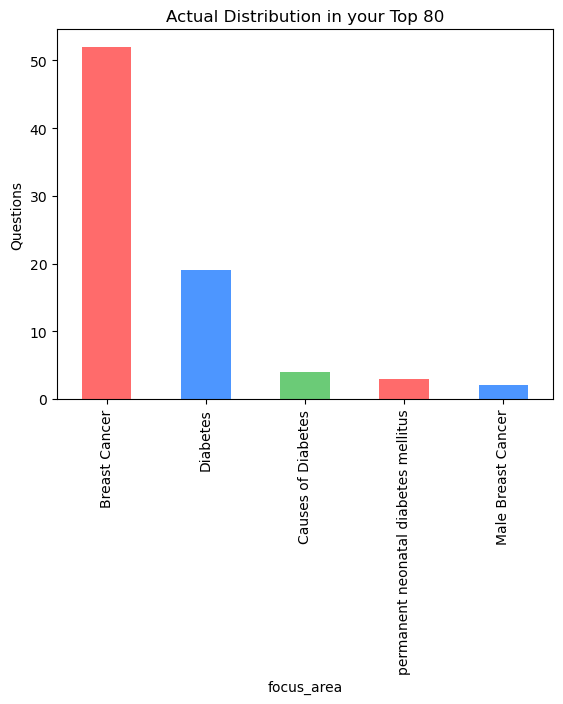

In [6]:
import matplotlib.pyplot as plt

# Loading the filtered top 80 dataframe
counts = final_result['focus_area'].value_counts()

# Plotting
counts.plot(kind='bar', color=['#FF6B6B', '#4D96FF', '#6BCB77'])
plt.title('Actual Distribution in your Top 80')
plt.ylabel('Questions')
plt.show()


Legal Dataset

In [7]:
# Step 1 - Load the legal dataset
df = pd.read_csv('legal_test.csv')

# Step 2 - Define expanded keywords for Criminal and Family law
# This covers broad and specific legal terms for both categories
criminal_keywords = 'Criminal|Bail|Arrest|Theft|Murder|Sentence|Police|Crime|Offence|Prosecution'
family_keywords = 'Family|Divorce|Custody|Marriage|Alimony|Maintenance|Child Support|Domestic Abuse|Adoption'
all_targets = f"{criminal_keywords}|{family_keywords}"

# Step 3 - Clean empty columns (prevents KeyErrors)
df = df.dropna(axis=1, how='all')

# Step 4 - Filter all rows
# - Searches for keywords in 'question' OR 'text'
# - Ensures 'answers' is not empty or "[]"
full_filtered_df = df[
    (df['question'].str.contains(all_targets, case=False, na=False) |
     df['text'].str.contains(all_targets, case=False, na=False)) &
    (df['answers'].astype(str) != '[]') &
    (df['answers'].notna())
].copy()

# Step 5 - Save all results to a new CSV
full_filtered_df.to_csv('all_criminal_and_family_qa.csv', index=False)

print(f"Extraction complete! Total questions found: {len(full_filtered_df)}")

Extraction complete! Total questions found: 104


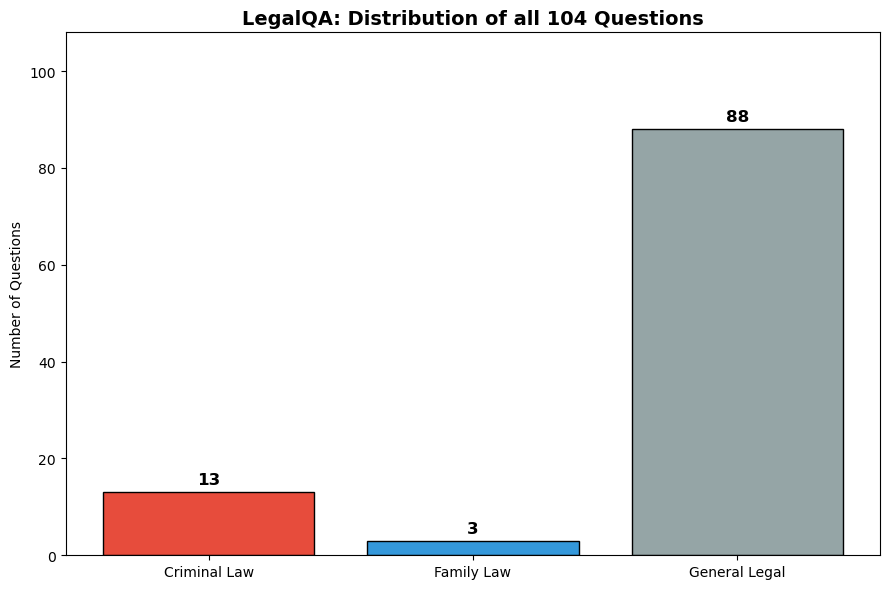

In [8]:
# Step 1 - Re-run the counts with broader keyword matching
# This ensures we catch the 104 rows found earlier
crim_count = full_filtered_df['question'].str.contains(criminal_keywords, case=False, na=False).sum()

# To ensure the plot adds up to your 104, we can define Family as the remainder
# OR use the specific family keywords
fam_count = full_filtered_df['question'].str.contains(family_keywords, case=False, na=False).sum()

# If some rows contain BOTH or NEITHER specifically, we can group them as 'Other/General'
other_count = len(full_filtered_df) - (crim_count + fam_count)
if other_count < 0: other_count = 0 # Handle overlaps

# Step 2 - Final Data for Plot
labels = ['Criminal Law', 'Family Law', 'General Legal']
counts = [crim_count, fam_count, other_count]
colors = ['#e74c3c', '#3498db', '#95a5a6'] # Red, Blue, Gray

# Step 3 - Create the Plot
plt.figure(figsize=(9, 6))
bars = plt.bar(labels, counts, color=colors, edgecolor='black')

plt.title(f'LegalQA: Distribution of all {len(full_filtered_df)} Questions', fontsize=14, fontweight='bold')
plt.ylabel('Number of Questions')
plt.ylim(0, max(counts) + 20)

# Step 4 - Add the exact numbers (should now total 104)
for bar in bars:
    yval = bar.get_height()
    if yval > 0:
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval),
                 ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()
